# Imports and Setup

In [1]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import Aer
from qiskit.visualization import plot_histogram

# 1. Bit-Flip Correction Code


Results: {'0': 242, '1': 270}


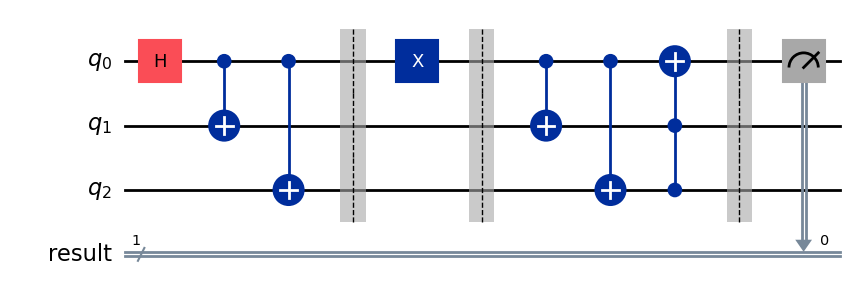

In [ ]:
# 1. Setup: We only need 3 qubits and 1 classical bit for the final result
q = QuantumRegister(3, 'q')
c = ClassicalRegister(1, 'result')

bit_flip_toffoli = QuantumCircuit(q, c)

# State Preparation (Encoding)
bit_flip_toffoli.h(q[0]) # First qubit in a superposition state with 50% probability of being 0 or 1
bit_flip_toffoli.cx(q[0], q[1])
bit_flip_toffoli.cx(q[0], q[2])

bit_flip_toffoli.barrier() # Visual separator

# Simulate Bit-flip error
# We simulate an error occurring on qubit 0 to test the Toffoli gate
bit_flip_toffoli.x(q[0]) 

bit_flip_toffoli.barrier()

# Toffoli Gate Correction (Decoding and Correction)
# We use CX gates to compare the states
bit_flip_toffoli.cx(q[0], q[1])
bit_flip_toffoli.cx(q[0], q[2])

# The Toffoli (ccx) gate corrects q[0] if q[1] and q[2] are 1
bit_flip_toffoli.ccx(q[2], q[1], q[0])

bit_flip_toffoli.barrier()

# Final Measurement 
# If the correction worked, q[0] should return to its original superposition state
bit_flip_toffoli.measure(q[0], c[0])

# 2. Execution
backend = Aer.get_backend('qasm_simulator')
job = backend.run(bit_flip_toffoli, shots=512)
bit_counts = job.result().get_counts()

print('\nResults:', bit_counts)

# 3. Draw the circuit
# If you are in VS Code, this will generate the circuit image
bit_flip_toffoli.draw(output='mpl')

# 2. Phase-Flip Correction Code


Results: {'0': 243, '1': 269}


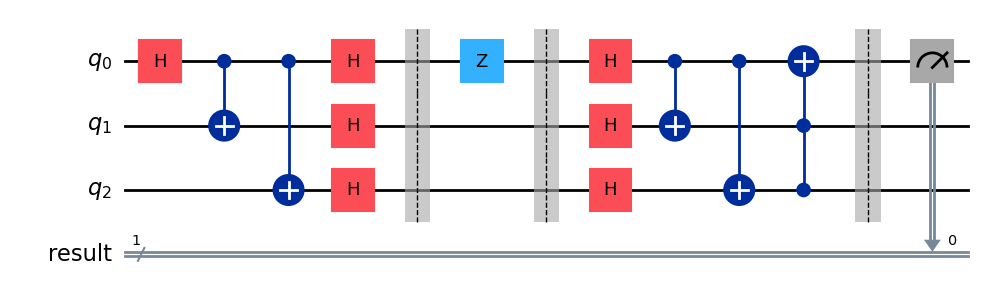

In [3]:
# 1. Setup: We only need 3 qubits and 1 classical bit for the final result
q = QuantumRegister(3, 'q')
c = ClassicalRegister(1, 'result')

phase_flip_toffoli = QuantumCircuit(q, c)

# State Preparation (Encoding) 
phase_flip_toffoli.h(q[0])
phase_flip_toffoli.cx(q[0], q[1])
phase_flip_toffoli.cx(q[0], q[2])

# Basis change to protect against phase errors
phase_flip_toffoli.h(q[0]) 
phase_flip_toffoli.h(q[1]) 
phase_flip_toffoli.h(q[2]) 

phase_flip_toffoli.barrier() # Visual separator

# Simulate Phase-flip error 
# We simulate a phase error occurring on qubit 0
phase_flip_toffoli.z(q[0]) 

phase_flip_toffoli.barrier()

# Revert basis change
phase_flip_toffoli.h(q[0]) 
phase_flip_toffoli.h(q[1]) 
phase_flip_toffoli.h(q[2]) 

# Correction (Decoding and Correction) 
# We use CX gates to compare the states
phase_flip_toffoli.cx(q[0], q[1])
phase_flip_toffoli.cx(q[0], q[2])

# The Toffoli (ccx) gate corrects q[0] if q[1] and q[2] are 1
phase_flip_toffoli.ccx(q[2], q[1], q[0])

phase_flip_toffoli.barrier()

# Final Measurement 
# If the correction worked, q[0] should return to its original superposition state
phase_flip_toffoli.measure(q[0], c[0])

# 2. Execution
backend = Aer.get_backend('qasm_simulator')
job = backend.run(phase_flip_toffoli, shots=512)
phase_counts = job.result().get_counts()

print('\nResults:', phase_counts)

# 3. Draw the circuit
phase_flip_toffoli.draw(output='mpl')

# 3. Study of State Convergence 


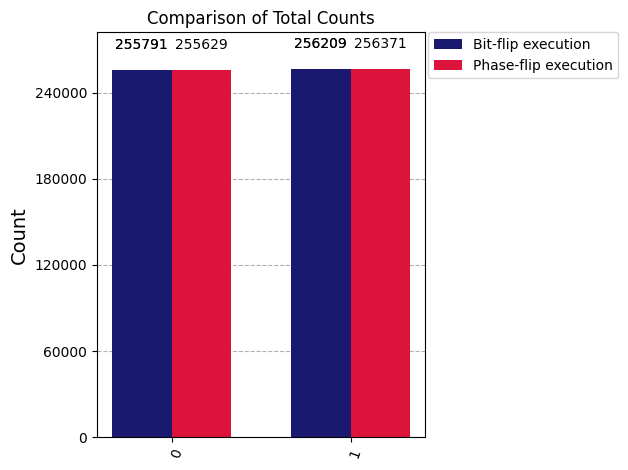

In [6]:
# Execution with a large number of shots 
backend = Aer.get_backend('qasm_simulator')

# We run the simulation with 512,000 shots
job_phase = backend.run(phase_flip_toffoli, shots=512000)
counts_phase = job_phase.result().get_counts()

job_bit = backend.run(bit_flip_toffoli, shots=512000)
counts_bit = job_bit.result().get_counts()

# Qiskit plot_histogram accepts a list of dictionaries to compare results
legend = ['Bit-flip execution', 'Phase-flip execution']
plot_histogram([counts_bit, counts_phase], 
               legend=legend, 
               color=['midnightblue', 'crimson'],
               title="Comparison of Total Counts")

We conclude that the error was successfully corrected, allowing the logical qubit to maintain its original superposition state with a 50% probability of being measured as 0 or 1.
